C:\Users\ketan\AppData\Local\Temp\ipykernel_68716\1955128726.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = plt.cm.get_cmap('gist_ncar', 48)


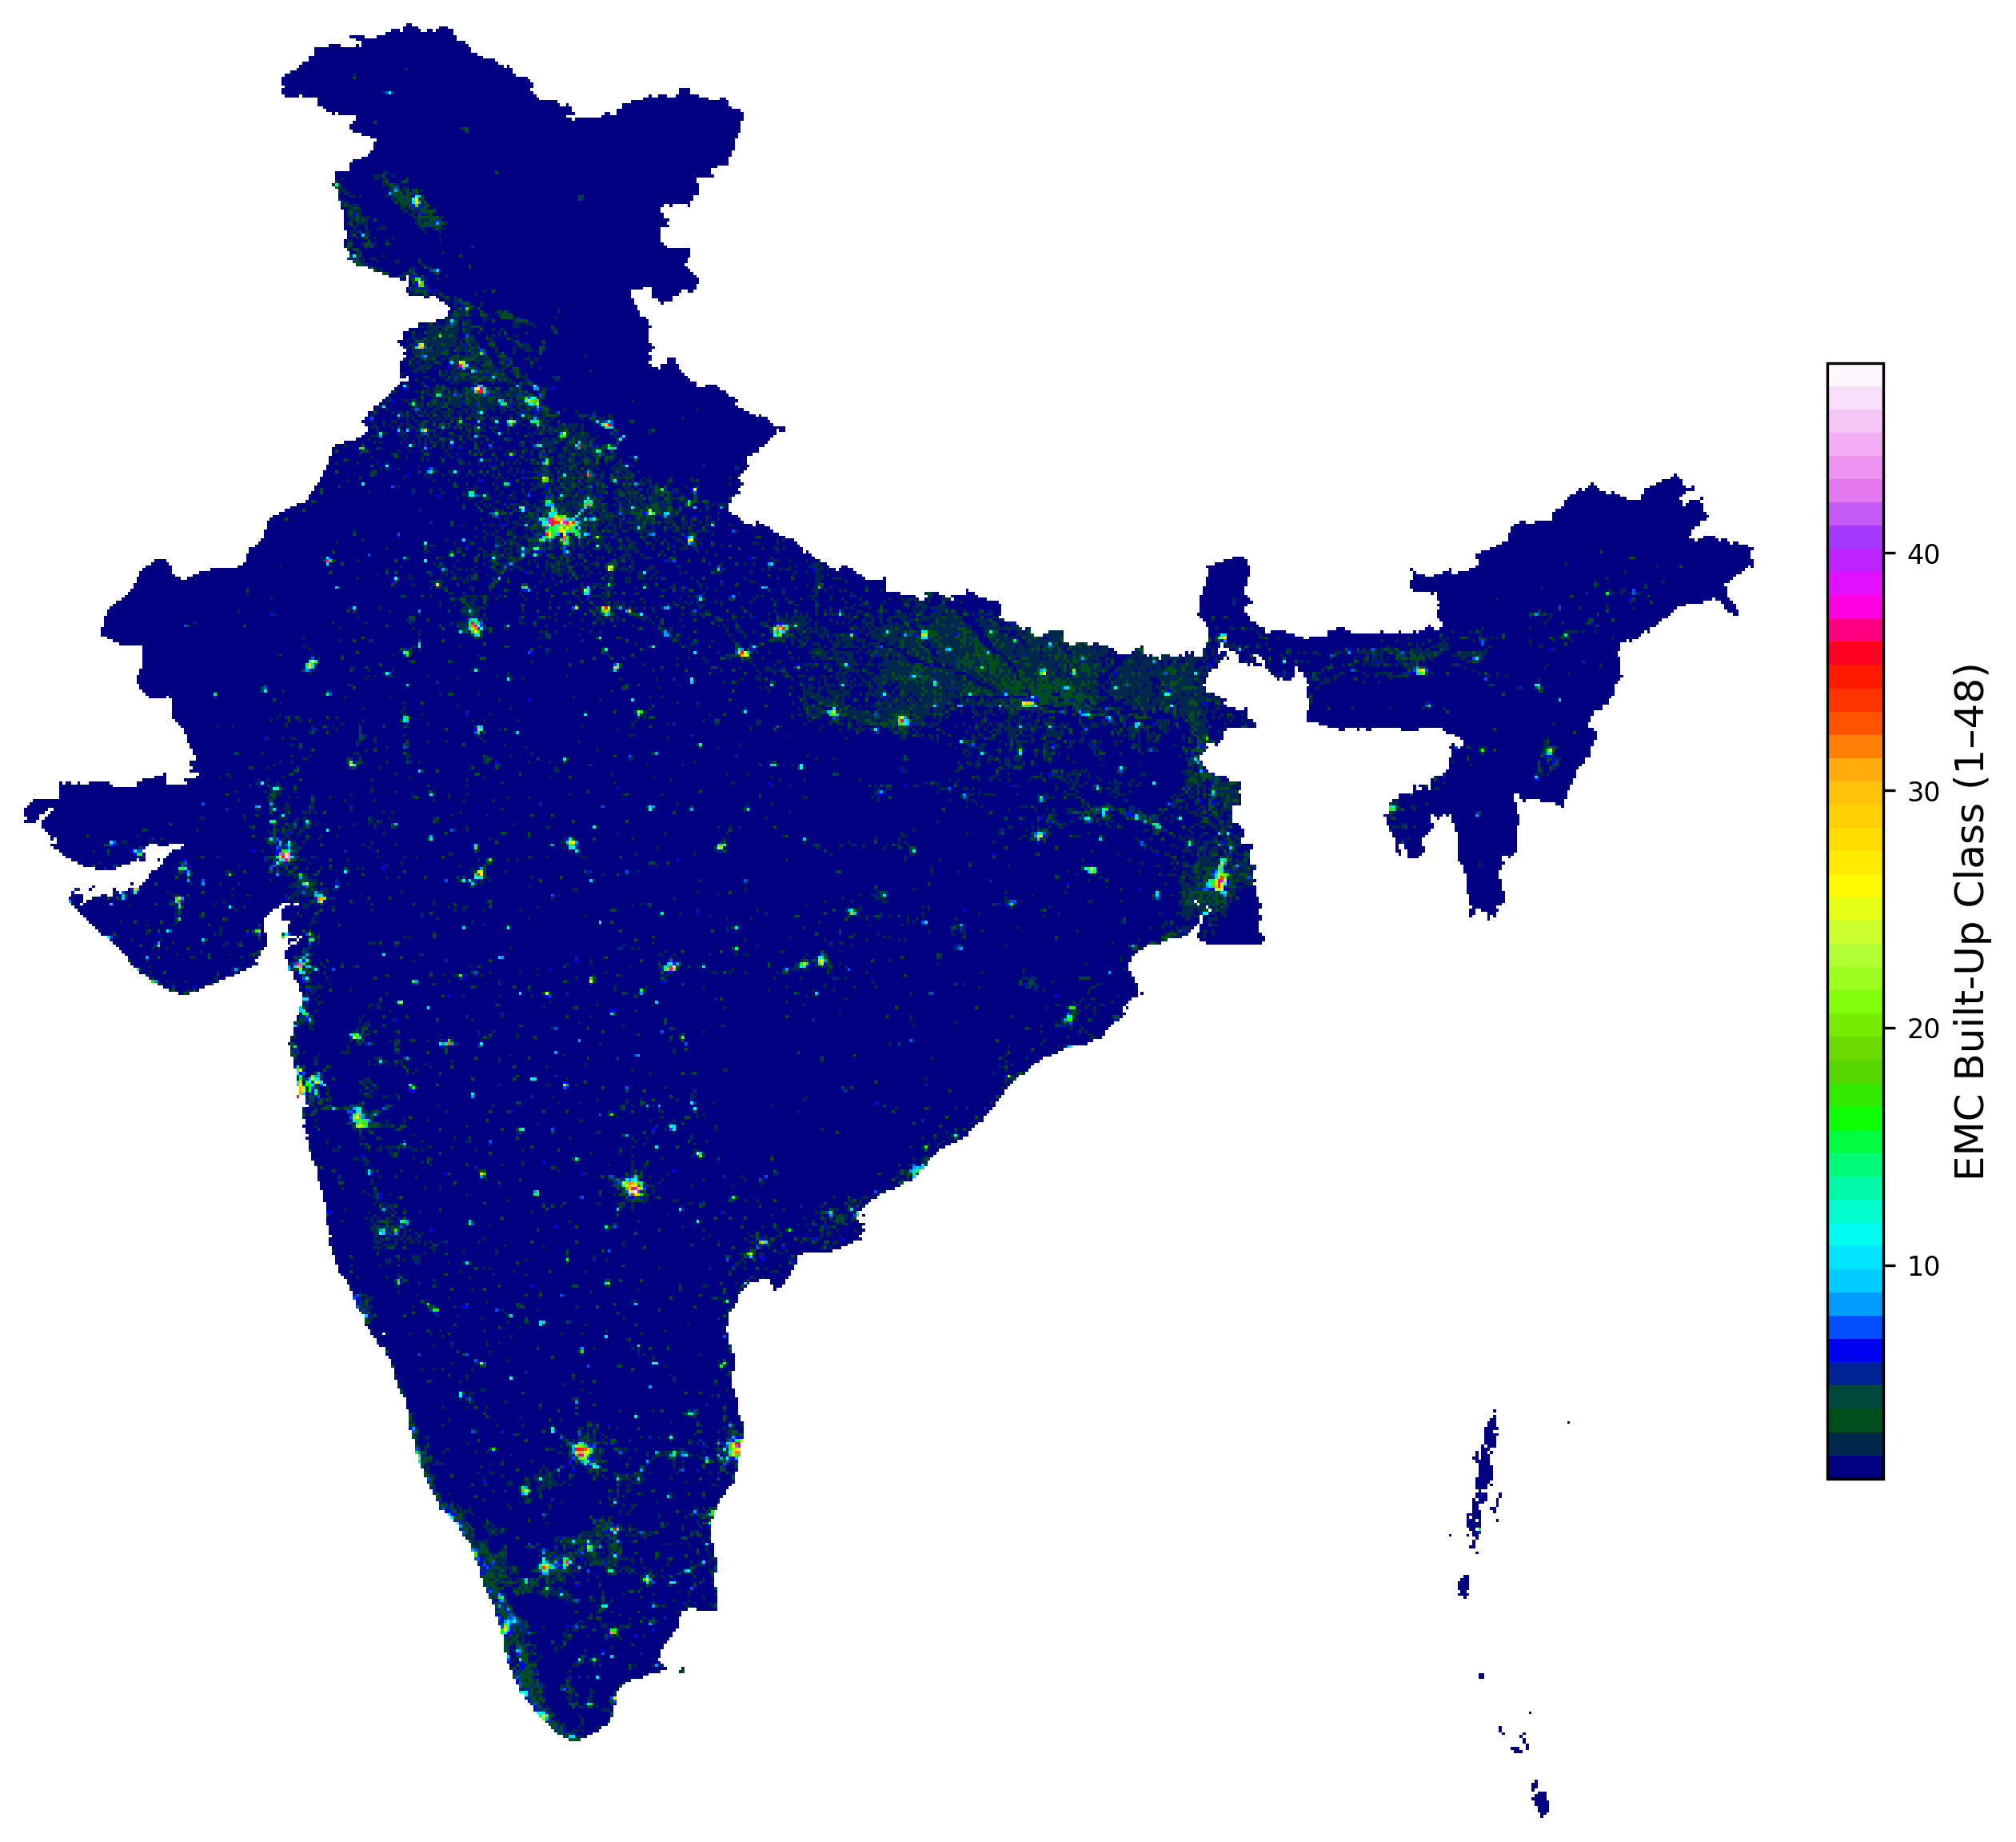

In [3]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# --- paths ---
tif_path = r"E:\EMC_BUILT_INDIA_005deg_CLIPPED.tif"
out_png = r"E:\EMC_BUILT_INDIA_005deg_CLIPPED_white.png"

# --- read raster ---
with rasterio.open(tif_path) as src:
    data = src.read(1).astype(float)
    nodata = src.nodata

# Mask nodata
if nodata is not None:
    data = np.where(data == nodata, np.nan, data)

# --- Define Palette ---
# 'gist_ncar' is still great for discrete classes
base_cmap = plt.cm.get_cmap('gist_ncar', 48) 
cmap = ListedColormap(base_cmap(np.arange(48)))
cmap.set_bad(color='none') # 'none' makes the background transparent/white

# --- Plotting ---
plt.figure(figsize=(10, 10), dpi=300, facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')

# Plot the data
img = ax.imshow(
    data,
    cmap=cmap,
    vmin=1, vmax=48,
    interpolation="nearest"
)

# Remove axes
ax.axis('off')

# Colourbar with black text for white background
cbar = plt.colorbar(img, fraction=0.03, pad=0.04)
cbar.set_label("EMC Built-Up Class (1–48)", color='black', fontsize=12)
cbar.ax.tick_params(labelsize=8, colors='black')

# Save with white background
plt.savefig(out_png, dpi=300, bbox_inches="tight", facecolor='white')
plt.show()